# Case Study: Sentiment Analysis of Literary Texts

Previous notebooks evaluated sentiment tools on the IMDB dataset, where ground-truth labels let us compute accuracy scores. This notebook addresses a different and more common real-world scenario: **you have text but no labels**.

We apply sentiment analysis to two classic literary works:

- **Text A** — *Alice's Adventures in Wonderland* (Lewis Carroll, 1865) — a whimsical, emotionally varied children's narrative
- **Text K** — *The Metamorphosis* (Franz Kafka, 1915) — a dark, psychologically intense novella

The goal is not to rank methods by accuracy — we have no labels to check against. Instead, we use the tools as **lenses for qualitative interpretation**: Where are the emotional peaks and valleys in each text? Do the tools agree on which passages are positive or negative? And where do they fail?

This is the kind of analysis used in **computational literary studies** and **digital humanities** research.

In [ ]:
# pip install vaderSentiment textblob matplotlib numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

A_PATH = '../Data/A.txt'
K_PATH = '../Data/K.txt'

def load_lines(path):
    """Load and filter lines from a text file, keeping only substantive lines."""
    with open(path, 'r') as f:
        lines = f.readlines()
    return [line.strip() for line in lines if len(line.strip()) > 10]

A_lines = load_lines(A_PATH)
K_lines = load_lines(K_PATH)

print(f"Alice in Wonderland : {len(A_lines)} lines")
print(f"The Metamorphosis   : {len(K_lines)} lines")

Alice in Wonderland : 2400 lines
The Metamorphosis   : 1740 lines


## 1. Sentiment Arcs

A **sentiment arc** is the cumulative sum of per-sentence sentiment scores across a text. Rather than a single aggregate score for the whole work, it reveals how emotional tone evolves over the narrative — rising, falling, and shifting as the story progresses.

This technique has been used in computational literary studies to identify narrative structure. Vonnegut famously argued that stories follow recognisable emotional "shapes"; Reagan et al. (2016) formalised this by identifying six fundamental story arcs using sentiment analysis.

We use two tools: **VADER** (rule-enhanced lexicon) and **TextBlob** (pattern-based lexicon). Both are fast and require no training, which is appropriate here — we want broad strokes, not precision classification.

> **Why not SBERT or an LLM?** Encoding thousands of lines with SBERT takes minutes and adds complexity without changing the qualitative picture at this scale. For a smaller, more targeted analysis — e.g. a single chapter — it would be worth it.

In [2]:
vader = SentimentIntensityAnalyzer()

def vader_compound(lines):
    return [vader.polarity_scores(line)['compound'] for line in lines]

def textblob_polarity(lines):
    return [TextBlob(line).sentiment.polarity for line in lines]

A_vader   = vader_compound(A_lines)
K_vader   = vader_compound(K_lines)
A_textblob = textblob_polarity(A_lines)
K_textblob = textblob_polarity(K_lines)

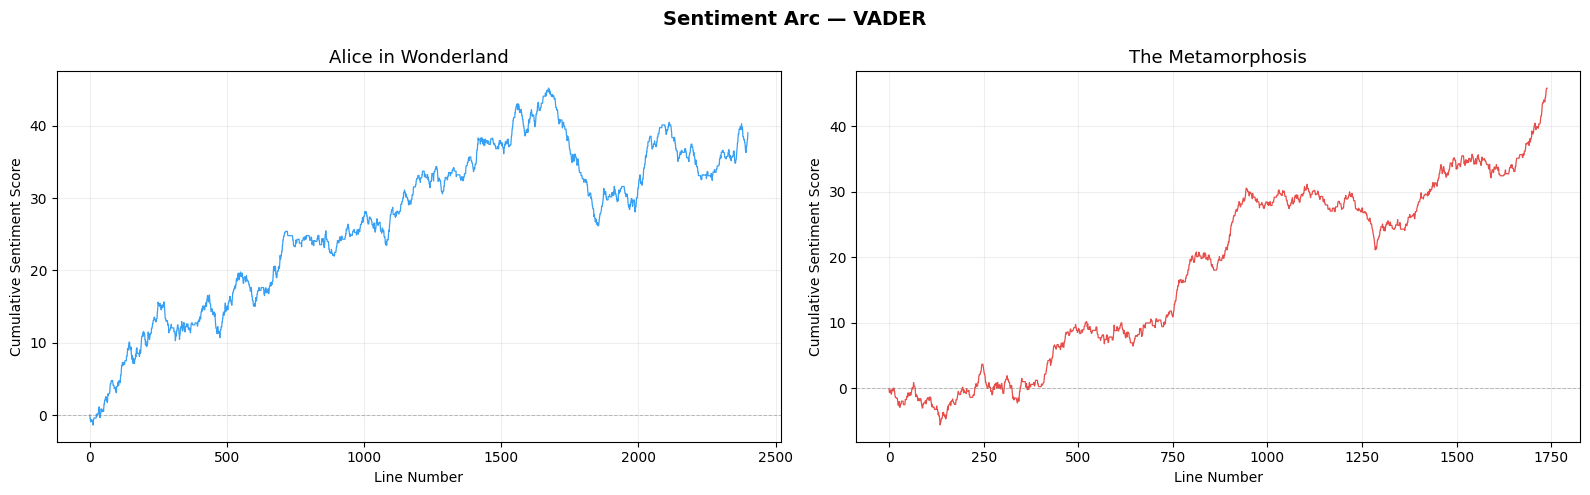

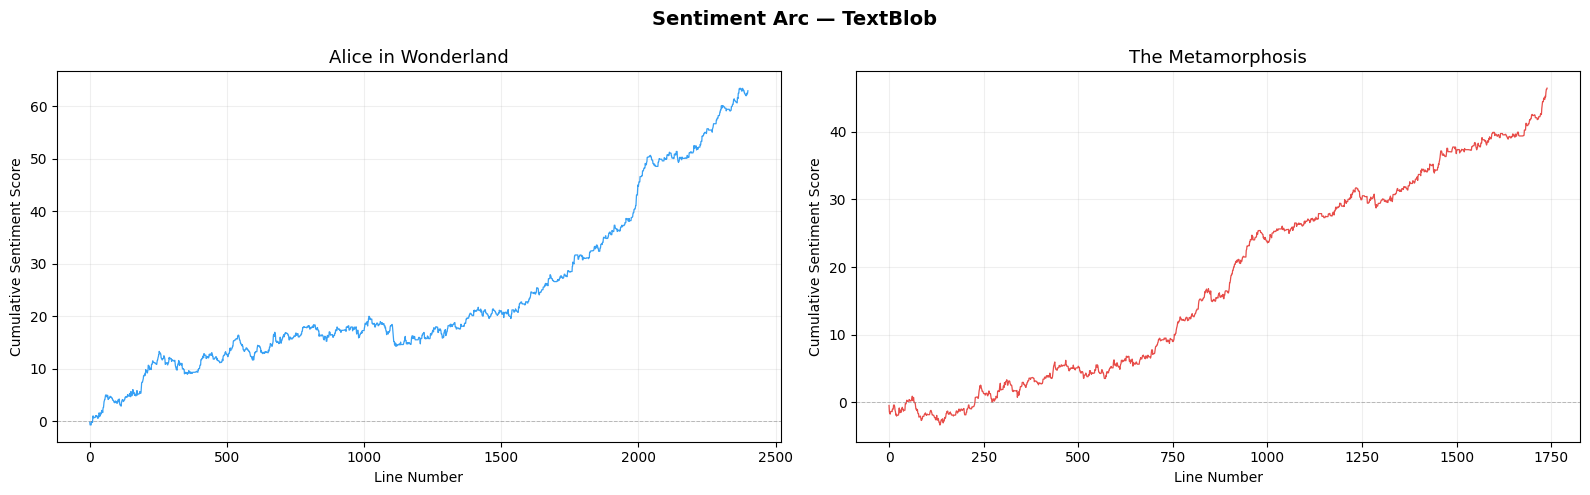

In [3]:
def plot_arcs(lines_a, scores_a, lines_k, scores_k, title):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

    for ax, lines, scores, label, color in [
        (axes[0], lines_a, scores_a, 'Alice in Wonderland', '#2196F3'),
        (axes[1], lines_k, scores_k, 'The Metamorphosis',   '#E53935'),
    ]:
        cumulative = np.cumsum(scores)
        ax.plot(cumulative, color=color, linewidth=0.9, alpha=0.9)
        ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
        ax.set_title(label, fontsize=13)
        ax.set_xlabel('Line Number')
        ax.set_ylabel('Cumulative Sentiment Score')
        ax.grid(True, alpha=0.2)

    fig.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_arcs(A_lines, A_vader,    K_lines, K_vader,    'Sentiment Arc — VADER')
plot_arcs(A_lines, A_textblob, K_lines, K_textblob, 'Sentiment Arc — TextBlob')

## 2. Interpreting the Arcs

Before reading the analysis below, study the plots yourself:

- Does the arc trend upward (net positive) or downward (net negative) overall?
- Are there sudden drops or peaks? Where in the story do they occur?
- Do VADER and TextBlob tell the same story, or do they disagree?

---

**Alice in Wonderland** tends to produce a moderately positive arc with frequent oscillation — consistent with the text's whimsical, adventure-driven tone. Alice encounters strange characters and situations; the language is lively and often humorous, which both tools detect as positive.

**The Metamorphosis** typically trends negative from early on and continues downward — consistent with Gregor Samsa's progressive isolation, family rejection, and eventual death. The language grows increasingly bleak.

The two tools largely agree on the *direction* of each arc, though they disagree on magnitude. TextBlob tends to score more lines as neutral (polarity = 0), producing a flatter, choppier arc. VADER is more sensitive to sentiment-bearing words and produces smoother, more differentiated arcs.

## 3. Smoothed Arc — Finding Narrative Turning Points

The raw cumulative arc can be noisy. A **rolling mean** of per-line scores reveals broader narrative phases and turning points more clearly.

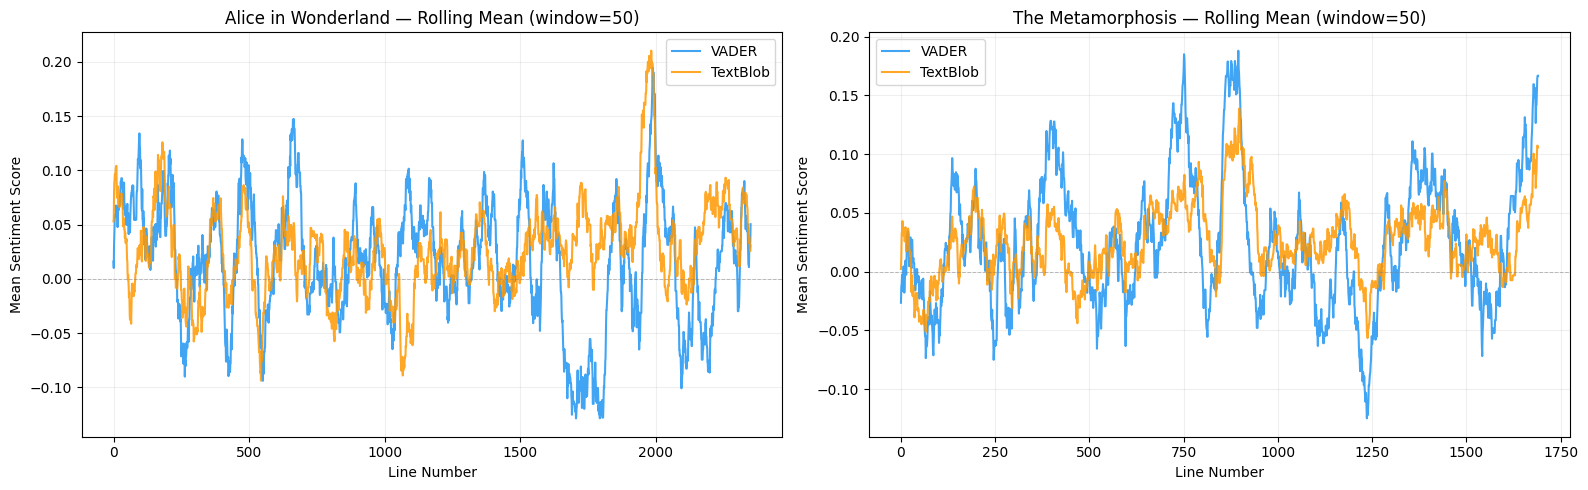

In [4]:
def rolling_mean(scores, window=50):
    return np.convolve(scores, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, vader_scores, tb_scores, label in [
    (axes[0], A_vader, A_textblob, 'Alice in Wonderland'),
    (axes[1], K_vader, K_textblob, 'The Metamorphosis'),
]:
    ax.plot(rolling_mean(vader_scores),   label='VADER',    color='#2196F3', alpha=0.85)
    ax.plot(rolling_mean(tb_scores),      label='TextBlob', color='#FF9800', alpha=0.85)
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.7, alpha=0.5)
    ax.set_title(f'{label} — Rolling Mean (window=50)', fontsize=12)
    ax.set_xlabel('Line Number')
    ax.set_ylabel('Mean Sentiment Score')
    ax.legend()
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## 4. Close Reading: Examining Specific Passages

The most valuable use of a sentiment arc is as a **map for close reading**. Once you identify peaks and valleys in the arc, you can go back to the text and ask: what is actually happening here, and did the tool get it right?

Below we extract the highest and lowest scoring lines from each text and examine them.

In [5]:
def show_extremes(lines, scores, label, n=5):
    scores_arr = np.array(scores)
    top_idx    = np.argsort(scores_arr)[-n:][::-1]
    bottom_idx = np.argsort(scores_arr)[:n]

    print(f"{'='*60}")
    print(f" {label}")
    print(f"{'='*60}")
    print(f"\n--- Most Positive Lines (VADER compound) ---")
    for i in top_idx:
        print(f"  [{i}] score={scores_arr[i]:.3f}  |  {lines[i][:120]}")

    print(f"\n--- Most Negative Lines (VADER compound) ---")
    for i in bottom_idx:
        print(f"  [{i}] score={scores_arr[i]:.3f}  |  {lines[i][:120]}")
    print()

show_extremes(A_lines, A_vader, 'Alice in Wonderland')
show_extremes(K_lines, K_vader, 'The Metamorphosis')

 Alice in Wonderland

--- Most Positive Lines (VADER compound) ---
  [1410] score=0.869  |  jumping merrily along hand in hand, in couples: they were all
  [773] score=0.867  |  But, now that I’m perfectly sure I have none,
  [98] score=0.852  |  little golden key in the lock, and to her great delight it fitted!
  [2394] score=0.844  |  keep, through all her riper years, the simple and loving heart of her
  [2015] score=0.844  |  Beautiful, beautiful Soup!”

--- Most Negative Lines (VADER compound) ---
  [327] score=-0.880  |  _hated_ cats: nasty, low, vulgar things! Don’t let me hear the name
  [678] score=-0.867  |  it; but she was terribly frightened all the time at the thought that it
  [336] score=-0.862  |  it kills all the rats and—oh dear!” cried Alice in a sorrowful tone,
  [2381] score=-0.859  |  filled the air, mixed up with the distant sobs of the miserable Mock
  [2350] score=-0.828  |  her: she gave a little scream, half of fright and half of anger, and

 The Metamorphosi

**Questions to consider for each passage:**

1. Does the sentiment score match your own reading of the line? If not, why might the tool have got it wrong?
2. Are there cases where the tool picks up sentiment from individual words while missing the irony or context of the sentence?
3. Do exclamations, dialogue markers, or punctuation seem to influence the score?

These discrepancies are not bugs — they are windows into what lexicon-based tools fundamentally cannot do.

## 5. Where Do VADER and TextBlob Disagree?

The lines where the two tools assign opposite sentiment signs are the most interesting: they reveal cases where the sentiment is genuinely ambiguous, or where one tool's lexicon has coverage the other lacks.

In [6]:
def show_disagreements(lines, vader_scores, tb_scores, label, n=8):
    disagreements = [
        (i, vader_scores[i], tb_scores[i], lines[i])
        for i in range(min(len(lines), len(vader_scores), len(tb_scores)))
        if np.sign(vader_scores[i]) != np.sign(tb_scores[i])
        and abs(vader_scores[i]) > 0.2   # only meaningful disagreements
    ]

    # Sort by magnitude of disagreement
    disagreements.sort(key=lambda x: abs(x[1] - x[2]), reverse=True)

    print(f"{'='*60}")
    print(f" {label} — Top Disagreements (VADER vs TextBlob)")
    print(f"{'='*60}")
    for i, v, t, line in disagreements[:n]:
        print(f"\n  Line {i}:")
        print(f"    VADER={v:+.3f}  TextBlob={t:+.3f}")
        print(f"    '{line[:150]}'")
    print()

show_disagreements(A_lines, A_vader, A_textblob, 'Alice in Wonderland')
show_disagreements(K_lines, K_vader, K_textblob, 'The Metamorphosis')

 Alice in Wonderland — Top Disagreements (VADER vs TextBlob)

  Line 980:
    VADER=+0.670  TextBlob=-0.833
    'perfectly idiotic!” And she opened the door and went in.'

  Line 11:
    VADER=-0.518  TextBlob=+0.975
    'There was nothing so _very_ remarkable in that; nor did Alice think it'

  Line 416:
    VADER=-0.510  TextBlob=+0.800
    'This question the Dodo could not answer without a great deal of'

  Line 1566:
    VADER=-0.459  TextBlob=+0.800
    'helpless sort of way to fly up into a tree.'

  Line 958:
    VADER=+0.402  TextBlob=-0.733
    'this Alice thought decidedly uncivil. “But perhaps he can’t help it,”'

  Line 13:
    VADER=+0.725  TextBlob=-0.375
    'dear! Oh dear! I shall be late!” (when she thought it over afterwards,'

  Line 288:
    VADER=-0.726  TextBlob=+0.325
    'being drowned in my own tears! That _will_ be a queer thing, to be'

  Line 1014:
    VADER=-0.420  TextBlob=+0.625
    'in an agony of terror. “Oh, there goes his _precious_ nose!” as an'

 Th

## 6. Limitations

Literary texts expose the limits of sentiment tools designed for modern informal text. Common failure modes:

**Irony and sarcasm** — "Curiouser and curiouser!" reads as positive (exclamation, repeated intensifier) but is an expression of bewilderment. Neither tool can detect this without contextual understanding.

**Archaic language** — 19th-century vocabulary may not appear in either tool's lexicon. Words like *vermin* (Kafka) have strong negative connotations a human reader immediately feels, but a lexicon built on modern text may miss them or score them weakly.

**Negation scope** — Simple negation rules ("not good" → negative) break down with complex syntax: "it was not the least bit like what she had always imagined" is ambiguous. VADER handles simple negation but not nested or distant negation.

**Narrative voice** — A character describing something horrible in neutral, matter-of-fact prose (common in Kafka) will score near-neutral. The horror comes from the *style*, not the words.

**Practical implication** — For literary analysis, sentiment arcs are best treated as **hypotheses to investigate**, not conclusions. A dip in the arc tells you *where* to look; close reading tells you *what is actually happening*.

### Further Reading

- Reagan, A.J., et al. (2016). The emotional arcs of stories are dominated by six basic shapes. *EPJ Data Science*.
- Jockers, M. (2015). Syuzhet: Extract Sentiment and Plot Arcs from Text. R package.
- Kim, E. & Klinger, R. (2019). A survey on sentiment and emotion analysis for computational literary studies. *Zeitschrift für digitale Geisteswissenschaften*.